# Cross-Sectional Momentum Signal — Research Notebook

End-to-end research pipeline for a **cross-sectional momentum** signal on crypto OHLCV data.
The core hypothesis: assets that have outperformed their peers over a trailing window — in raw, peer-relative, or volatility-adjusted terms — tend to keep outperforming over the holding horizon.

| Section | Topic |
|---------|-------|
| §1 | Setup — project root, imports, display options |
| §2 | Configuration — load `configs/research/momentum_signal.yaml` + DB engine |
| §3 | Data — load universe & OHLCV panel |
| §4 | Signal Pipeline — build signal, feature panels & forward returns |
| §5 | IC Analysis — per-feature IC / t-stat across core, relative, vol-adjusted & residual families |
| §6 | Diagnostics — IC distribution, rolling IC, coverage, quantiles |
| §7 | Backtest — long/short PnL, fee-tier sensitivity, beta-neutral variants, market-neutrality diagnostics |
| §8 | Execution — rolling Sharpe, one-bar execution delay |
| §9 | Robustness — horizon × skip × holding × universe-size grid; selection-adjusted significance; walk-forward; residual-momentum stability |
| §10 | Detailed findings |

All timestamps are **UTC**; run cells top to bottom (later sections reuse panels built earlier).

**Dependencies:** `cs_momentum`, `momentum_eval`, `robustness`, `panel_io`, `research_config`; a populated Postgres DB (OHLCV + universe tables).

## Summary — Key Findings

**Signal:** cross-sectional momentum on 24h bars (top-20 Kraken USD pairs, 2020-10 → 2024-06), scanning 35 features and a lookback × skip × holding × universe grid. Costs: 10 bps one-way taker fee (an institutional volume tier, i.e. a systematic fund's cost base) plus half-spread on every fill.

| Metric | Value |
|---|---|
| Selected signal IC t-stat, raw / Newey-West | 3.15 / 1.54 |
| Best grid NW t; max-over-trials p (4 families) | 1.97; 0.09 |
| Deflated Sharpe probability (240 trials) | 0.28 |
| Walk-forward out-of-sample IC (NW t) | 0.003 (0.12) |
| Net Sharpe at 10 bps / 40 bps (retail) fee | 1.53 / 1.26 |
| Residual-momentum IC (NW t) | −0.003 (−0.10) |

- **No robust momentum signal.** The best configuration is a selection effect: insignificant after Newey-West correction, indistinguishable from the best of 240 noise trials, and without out-of-sample IC (§9).
- **The book was a disguised market bet.** It carried offsetting regime betas behind a near-zero full-sample correlation; momentum on beta-residualised returns has zero IC (§7, §9).
- **Neutrality is affordable; alpha is missing.** A benchmark hedge removes the beta at matched capital for a small Sharpe cost (§7).
- **The test is underpowered.** ~14 names and ~90 non-overlapping periods cannot detect a realistic IC of 0.02–0.03; this argues for breadth (perpetual futures), not more features.

Supporting evidence for each point is in §10.


## §1 Setup

Locate the project root (`src/` + `configs/`), add it to `sys.path`, and import the momentum signal builders and `momentum_eval` evaluation helpers.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common.db import make_engine
from src.common.research_config import load_research_settings
from src.data.panel_io import fetch_ohlcv_long, list_universe_symbols
from src.signals.cs_momentum import (
    apply_rebalance_decimation,
    apply_traded_mask,
    apply_universe_mask,
    build_feature_panels,
    build_market_index_returns,
    build_momentum_signal,
    build_residual_momentum_signal,
    build_selected_momentum_signal,
    build_traded_mask,
    compute_forward_returns,
    estimate_rolling_betas,
    select_momentum_feature_panel,
    to_simple_returns,
)
from src.research.momentum_eval import (
    build_beta_hedged_weights,
    build_quantile_weights,
    compute_ic_series,
    compute_ic_decay_heatmap,
    feature_ic_row,
    plot_ic_decay_heatmap,
    quantile_analysis,
    ic_summary,
    long_short_leg_returns,
    market_correlation,
    rolling_mean,
    rolling_sharpe,
    run_light_backtest,
    max_over_trials_pvalue,
    deflated_sharpe_ratio,
    walk_forward_ic_table,
    walk_forward_selection,
    portfolio_beta_series,
    realized_beta_diagnostics,
)
from src.research.robustness import run_momentum_grid

pd.options.display.float_format = "{:.6f}".format

## §2 Configuration

Load research parameters from `configs/research/momentum_signal.yaml` and open the DB engine. Key knobs: signal timeframe, lookback and skip windows, cross-sectional transform, fee/spread assumptions, the feature-horizon and holding-period grids, and the train/test split date.

In [2]:
settings = load_research_settings("configs/research/momentum_signal.yaml")
engine = make_engine(settings)

settings_preview_keys = [
    "signal_timeframe",
    "ic_rebalance_bars",
    "holding_period_bars",
    "momentum_lookback_bars",
    "momentum_skip_bars",
    "cross_sectional_transform",
    "log_returns",
    "residual_space",
    "fee_bps",
    "half_spread_bps",
    "feature_horizons_bars",
    "momentum_skip_grid_bars",
    "holding_period_grid_bars",
    "universe_top_n_grid",
    "train_split_date",
]

{k: settings[k] for k in settings_preview_keys}

{'signal_timeframe': '24h',
 'ic_rebalance_bars': 1,
 'holding_period_bars': 20,
 'momentum_lookback_bars': 30,
 'momentum_skip_bars': 1,
 'cross_sectional_transform': 'rank',
 'log_returns': True,
 'residual_space': 'log',
 'fee_bps': 10.0,
 'half_spread_bps': 1.0,
 'feature_horizons_bars': [5, 10, 20, 40, 60],
 'momentum_skip_grid_bars': [1, 2, 3],
 'holding_period_grid_bars': [1, 3, 5, 10, 14, 21, 30, 40],
 'universe_top_n_grid': [10, 20],
 'train_split_date': Timestamp('2022-06-30 23:59:59+0000', tz='UTC')}

## §3 Data

Pull the **monthly rebalance universe** (rank-filtered liquid names) and long-format OHLCV for the research date range. This is the only cell that hits the database; all downstream sections work in-memory on `df_long`.

In [3]:
if settings.get("use_monthly_universe", True):
    universe_df = list_universe_symbols(
        engine,
        as_of_date=None,
        top_n=settings.get("max_assets") or settings.get("top_n"),
    )
    universe_df["rebalance_date"] = pd.to_datetime(universe_df["rebalance_date"], utc=True)
    universe_df = universe_df[
        (universe_df["rebalance_date"] >= settings["data_start_date"].normalize())
        & (universe_df["rebalance_date"] <= settings["data_end_date"].normalize())
    ]
    symbols = sorted(universe_df["symbol"].unique().tolist())
else:
    universe_df = None
    symbols = None

df_long = fetch_ohlcv_long(
    engine,
    start_ts=settings["data_start_date"],
    end_ts=settings["data_end_date"],
    symbols=symbols,
)

print(
    f"rows={len(df_long):,}, symbols={df_long['symbol'].nunique() if not df_long.empty else 0}, "
    f"monthly_points={0 if universe_df is None else universe_df['rebalance_date'].nunique()}"
)
df_long.head()

rows=1,704,347, symbols=64, monthly_points=43


,ts,symbol,open,high,low,close,volume,trades,dollar_volume
0,2020-10-01 00:00:00+00:00,ADA/USD,0.101470,0.103027,0.101280,0.102487,560347.337848,76,57428.317614
1,2020-10-01 00:00:00+00:00,ALGO/USD,0.346680,0.348180,0.344000,0.346350,27848.415930,31,9645.298857
2,2020-10-01 00:00:00+00:00,ATOM/USD,5.375300,5.448400,5.375300,5.423300,520.910352,19,2825.053111
3,2020-10-01 00:00:00+00:00,BAT/USD,0.241720,0.241850,0.241720,0.241850,6992.920526,4,1691.237829
4,2020-10-01 00:00:00+00:00,BCH/USD,228.100000,228.600000,228.100000,228.200000,148.447284,39,33875.670261


## §4 Signal Pipeline

Build the momentum signal and supporting panels in sequence:

1. `build_momentum_signal` — resample OHLCV to the signal timeframe, apply the monthly universe mask, and cross-sectionally rank/z-score.
2. `compute_forward_returns` — the prediction target for IC and backtest, matched to the selected holding period.
3. `build_feature_panels` — core, relative, and vol-adjusted feature families for the IC comparison in §5 (the residual family is added once betas are estimated, below).

The resulting wide panels (`signal`, `close_wide`, `universe_mask`) are reused by all downstream sections.

In [4]:
signal_pack = build_momentum_signal(
    df_long=df_long,
    signal_timeframe=settings["signal_timeframe"],
    momentum_lookback_bars=settings["momentum_lookback_bars"],
    momentum_skip_bars=settings["momentum_skip_bars"],
    universe_df=universe_df,
    cross_sectional_transform=settings["cross_sectional_transform"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    log_returns=settings["log_returns"],
    ic_rebalance_bars=settings["ic_rebalance_bars"],
)

signal = signal_pack["signal"]
close_wide = signal_pack["close_wide"]
universe_mask = signal_pack["universe_mask"]

# Features and forward returns share the signal-timeframe panel so that the
# IC analysis is on the same cadence and universe as the actual backtest.
fwd_ret = compute_forward_returns(
    close_wide,
    holding_period_bars=settings["holding_period_bars"],
    log_returns=settings["log_returns"],
)

feature_pack = build_feature_panels(
    close_wide=close_wide,
    horizons=settings["feature_horizons_bars"],
    benchmark_symbol=settings["benchmark_symbol"],
    vol_window_bars=settings["vol_window_bars"],
    log_returns=settings["log_returns"],
    residual_space=settings["residual_space"],
    universe_mask=universe_mask,
    skip_bars=settings["momentum_skip_bars"],
)

universe_fwd_ret = apply_universe_mask(fwd_ret, universe_mask)
xsec_universe_fwd_ret = universe_fwd_ret.sub(universe_fwd_ret.mean(axis=1), axis=0)

# Reference value kept for display only. Downstream cells use:
#   - Feature scan (bar-by-bar IC):  max(H, R) - 1  per feature
#   - Selected signal (D-subsampled IC):  (max(H, R) - 1) // D
# where R is the feature horizon / signal lookback.
baseline_nw_lag = max(
    int(settings["holding_period_bars"]),
    int(settings["momentum_lookback_bars"]),
) - 1

{
    "signal_shape": signal.shape,
    "close_wide_shape": close_wide.shape,
    "universe_fwd_ret_shape": universe_fwd_ret.shape,
    "baseline_nw_lag": baseline_nw_lag,
}

{'signal_shape': (1369, 64),
 'close_wide_shape': (1369, 64),
 'universe_fwd_ret_shape': (1369, 64),
 'baseline_nw_lag': 29}

### Beta Inputs — Market Indices & Rolling Betas

Builds the market-return series and rolling beta panels the rest of the notebook depends on, and **rebuilds the feature pack to include the residual-momentum signal** so §5 can score it alongside the other feature families. Two factors are estimated deliberately: **equal-weight universe** betas feed the residual-momentum *feature* (the benchmark's own residual would otherwise be identically zero), while **XBT/USD** betas, from the tradable hedge instrument, feed the §7 diagnostics and hedge overlay. Betas use traded-masked returns so forward-filled no-trade bars do not attenuate the covariances.

In [5]:
# --- Market indices, rolling betas --------------------------------------------
# Betas are estimated on traded-masked returns: forward-filled no-trade bars
# print 0% and bias Cov/Var toward 0 on illiquid names. Bar returns need both
# endpoints real -> lookback_bars=1.
#
# Two beta panels, each used where its benchmark is strongest:
#   * EW-universe betas -> the residual-momentum FEATURE. Avoids the
#     benchmark-mode degeneracy where XBT's own residual is identically 0,
#     which would park it mid-rank in every residual feature.
#   * XBT betas -> the hedge overlay + exposure DIAGNOSTICS. The hedge trades
#     the benchmark itself, so factor and hedge coincide (beta_bench = 1, no
#     basis risk). Estimated on SIMPLE returns to match the arithmetic
#     P&L the hedge offsets; the EW feature panel stays in log space.
traded_mask = build_traded_mask(df_long, settings["signal_timeframe"])
return_wide_traded = apply_traded_mask(
    signal_pack["return_wide"], traded_mask, lookback_bars=1
)
return_wide_traded_simple = to_simple_returns(
    return_wide_traded, log_returns=settings["log_returns"]
)

# Residual-feature factor: cross-sectional index (settings-driven; EW default).
market_ret_ew = build_market_index_returns(
    return_wide_traded,
    mode=settings["market_index_mode"],
    benchmark_symbol=settings["benchmark_symbol"],
    universe_mask=universe_mask,
    min_assets=settings["min_assets_per_timestamp"],
)
betas_ew = estimate_rolling_betas(
    return_wide_traded,
    market_ret_ew,
    window_bars=settings["beta_window_bars"],
    min_periods=settings["beta_min_periods_bars"],
    shrinkage=settings["beta_shrinkage"],
    shrink_target=settings["beta_shrink_target"],
)

# Hedge/diagnostics factor: the tradable benchmark itself (simple returns).
market_ret_xbt = build_market_index_returns(
    return_wide_traded_simple,
    mode="benchmark",
    benchmark_symbol=settings["benchmark_symbol"],
)
betas_xbt = estimate_rolling_betas(
    return_wide_traded_simple,
    market_ret_xbt,
    window_bars=settings["beta_window_bars"],
    min_periods=settings["beta_min_periods_bars"],
    shrinkage=settings["beta_shrinkage"],
    shrink_target=settings["beta_shrink_target"],
)

# Rebuild the feature pack with the residual-momentum family included (EW betas).
feature_pack = build_feature_panels(
    close_wide=close_wide,
    horizons=settings["feature_horizons_bars"],
    benchmark_symbol=settings["benchmark_symbol"],
    vol_window_bars=settings["vol_window_bars"],
    log_returns=settings["log_returns"],
    residual_space=settings["residual_space"],
    universe_mask=universe_mask,
    skip_bars=settings["momentum_skip_bars"],
    beta_panel=betas_ew,
    market_returns=market_ret_ew,
)

_uni_cells = float(universe_mask.sum().sum()) if universe_mask is not None else float(betas_xbt.size)
_b_ew_uni = betas_ew.where(universe_mask) if universe_mask is not None else betas_ew
_b_xbt_uni = betas_xbt.where(universe_mask) if universe_mask is not None else betas_xbt
{
    "beta_window_bars": int(settings["beta_window_bars"]),
    "beta_shrinkage": float(settings["beta_shrinkage"]),
    "median_universe_beta_ew": float(_b_ew_uni.median(axis=1).median()),
    "median_universe_beta_xbt": float(_b_xbt_uni.median(axis=1).median()),
    "beta_coverage_of_universe": float(_b_xbt_uni.notna().sum().sum() / max(_uni_cells, 1.0)),
}


{'beta_window_bars': 90,
 'beta_shrinkage': 0.2,
 'median_universe_beta_ew': 0.9847302388806973,
 'median_universe_beta_xbt': 1.0446767868141562,
 'beta_coverage_of_universe': 1.0}

## §5 IC Analysis

Build a comparison table of mean IC and NW-adjusted t-stat across the core, relative, vol-adjusted and residual feature families, then select the best-performing feature as the working signal for the rest of the notebook.

Newey-West lag accounts for overlapping forward returns, lookback windows, and rebalance decimation.

In [6]:
feature_rows = []
min_assets = settings["min_assets_per_timestamp"]
_H_scan = int(settings["holding_period_bars"])


def _scan_row(name, panel, forward_returns, nw_lag):
    stats = feature_ic_row(
        apply_universe_mask(panel, universe_mask), forward_returns,
        nw_lag=nw_lag, min_assets=min_assets,
    )
    return {"feature": name, **{k: stats[k] for k in ("mean_ic", "t_stat_ic", "t_stat_ic_nw")}}


# Features in this scan are raw (no rebalance decimation), so the NW lag only
# needs to cover forward-return overlap (H) and signal-lookback overlap (R=horizon).
# Relative features are scored against cross-sectionally demeaned returns.
for horizon in settings["feature_horizons_bars"]:
    nw_h = max(_H_scan, int(horizon)) - 1
    feature_rows.append(_scan_row(
        f"core_ret_{horizon}bar", feature_pack["core_returns"][horizon], universe_fwd_ret, nw_h
    ))
    for rel_name, rel_panel in feature_pack["relative_features"][horizon].items():
        feature_rows.append(_scan_row(f"{rel_name}_{horizon}bar", rel_panel, xsec_universe_fwd_ret, nw_h))
    for vol_name in ["return_over_vol", "zscored_return"]:
        feature_rows.append(_scan_row(
            f"{vol_name}_{horizon}bar", feature_pack["vol_adjusted_features"][horizon][vol_name],
            universe_fwd_ret, nw_h,
        ))
    for resid_name, resid_panel in feature_pack["residual_features"][horizon].items():
        feature_rows.append(_scan_row(f"{resid_name}_{horizon}bar", resid_panel, universe_fwd_ret, nw_h))

feature_ic_table = pd.DataFrame(feature_rows).sort_values("mean_ic", ascending=False)
feature_ic_table.head(20)


,feature,mean_ic,t_stat_ic,t_stat_ic_nw
25,zscored_return_40bar,0.027473,3.278934,1.469203
18,zscored_return_20bar,0.017832,2.135160,1.018519
6,residual_momentum_scaled_5bar,0.011363,1.198639,0.672597
5,residual_momentum_5bar,0.006884,0.714055,0.397332
2,minus_benchmark_5bar,0.006874,0.750989,0.450653
0,core_ret_5bar,0.006874,0.750989,0.450653
1,minus_xsec_mean_5bar,0.006874,0.750989,0.450653
9,minus_benchmark_10bar,0.006119,0.698039,0.299127
7,core_ret_10bar,0.006119,0.698039,0.299127
8,minus_xsec_mean_10bar,0.006119,0.698039,0.299127


### IC Decay Heatmap — Signal × Holding Period

This heatmap sweeps candidate signals across a grid of holding periods and reports the Newey-West-adjusted IC t-stat for each. A signal that holds a high t-stat at longer holding periods is more persistent and tolerates slower (cheaper) rebalancing; one whose t-stat collapses quickly only works at short horizons, where turnover costs bite.

**Newey-West lag.** Overlapping windows induce serial correlation in the IC series, so the iid t-stat is too optimistic. Two IC observations stay correlated as long as they share *either* forward-return data (up to `H − 1` bars apart) *or* signal-lookback data (up to `R − 1` bars apart), so the binding truncation lag is `max(H, R) − 1` — the *larger* of the two overlaps, not their sum. Using `nw_lag = 0` would understate the standard error and inflate the t-stat at longer horizons.

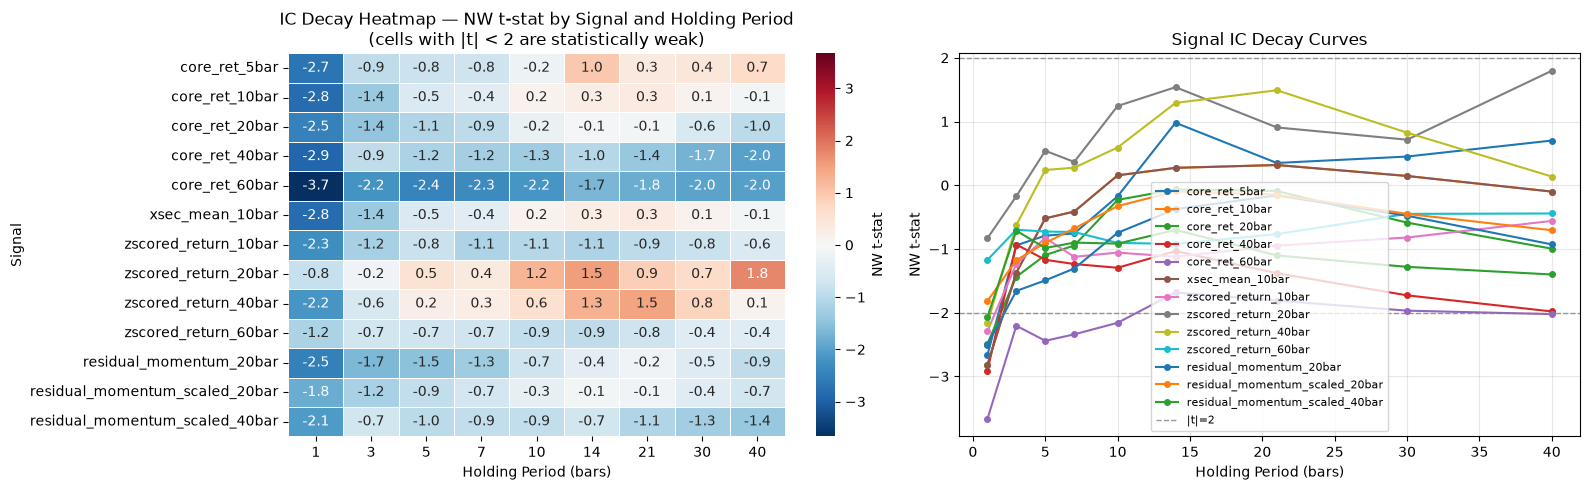

Signal                    | Peak hold |   Peak t |  t @ h=1 | Zero-cross hold
------------------------------------------------------------------------
core_ret_5bar             |        14 |     0.98 |    -2.67 | ~1
core_ret_10bar            |        21 |     0.32 |    -2.82 | ~1
core_ret_20bar            |        14 |    -0.07 |    -2.49 | ~1
core_ret_40bar            |         3 |    -0.93 |    -2.91 | ~1
core_ret_60bar            |        14 |    -1.68 |    -3.67 | ~1
xsec_mean_10bar           |        21 |     0.32 |    -2.82 | ~1
zscored_return_10bar      |        40 |    -0.56 |    -2.29 | ~1
zscored_return_20bar      |        40 |     1.80 |    -0.83 | ~1
zscored_return_40bar      |        21 |     1.49 |    -2.17 | ~1
zscored_return_60bar      |        40 |    -0.44 |    -1.17 | ~1
residual_momentum_20bar   |        21 |    -0.16 |    -2.50 | ~1
residual_momentum_scaled_20bar |        14 |    -0.10 |    -1.82 | ~1
residual_momentum_scaled_40bar |        14 |    -0.70 |    -2.07

In [7]:
holding_period_grid = [1, 3, 5, 7, 10, 14, 21, 30, 40]

# Candidate panels; horizons must exist in settings["feature_horizons_bars"].
candidate_signals = {
    "core_ret_5bar":  feature_pack["core_returns"][5],
    "core_ret_10bar": feature_pack["core_returns"][10],
    "core_ret_20bar": feature_pack["core_returns"][20],
    "core_ret_40bar": feature_pack["core_returns"][40],
    "core_ret_60bar": feature_pack["core_returns"][60],
    "xsec_mean_10bar": feature_pack["relative_features"][10]["minus_xsec_mean"],
    "zscored_return_10bar": feature_pack["vol_adjusted_features"][10]["zscored_return"],
    "zscored_return_20bar": feature_pack["vol_adjusted_features"][20]["zscored_return"],
    "zscored_return_40bar": feature_pack["vol_adjusted_features"][40]["zscored_return"],
    "zscored_return_60bar": feature_pack["vol_adjusted_features"][60]["zscored_return"],
    "residual_momentum_20bar": feature_pack["residual_features"][20]["residual_momentum"],
    "residual_momentum_scaled_20bar": feature_pack["residual_features"][20]["residual_momentum_scaled"],
    "residual_momentum_scaled_40bar": feature_pack["residual_features"][40]["residual_momentum_scaled"],
}
candidate_signals = {k: apply_universe_mask(v, universe_mask) for k, v in candidate_signals.items()}

# Feature lookback for each signal — drives NW lag = max(feature_horizon, h) - 1.
feature_horizons = {
    "core_ret_5bar":  5,
    "core_ret_10bar": 10,
    "core_ret_20bar": 20,
    "core_ret_40bar": 40,
    "core_ret_60bar": 60,
    "xsec_mean_10bar": 10,
    "zscored_return_10bar": 10,
    "zscored_return_20bar": 20,
    "zscored_return_40bar": 40,
    "zscored_return_60bar": 60,
    "residual_momentum_20bar": 20,
    "residual_momentum_scaled_20bar": 20,
    "residual_momentum_scaled_40bar": 40,
}

t_stat_heatmap, mean_ic_heatmap = compute_ic_decay_heatmap(
    candidate_signals=candidate_signals,
    close_wide=close_wide,
    holding_period_grid=holding_period_grid,
    log_returns=settings["log_returns"],
    min_assets=settings["min_assets_per_timestamp"],
    feature_horizons=feature_horizons,
)

plot_ic_decay_heatmap(t_stat_heatmap)

In [8]:
# ---- Select signal and holding period based on IC decay heatmap above -------
feature_family = "vol_adjusted"  # baseline | core | relative | vol_adjusted | residual
feature_horizon = 20
relative_feature = "minus_xsec_mean"  # for feature_family="relative"
vol_feature = "zscored_return"  # for feature_family="vol_adjusted"
residual_feature = "residual_momentum_scaled"  # for feature_family="residual"
apply_xsec_transform = True
apply_rebalance_decimation_flag = True
selected_holding_period = 14

fwd_ret = compute_forward_returns(
    close_wide, holding_period_bars=selected_holding_period, log_returns=settings["log_returns"]
)

raw_panel, signal_label = select_momentum_feature_panel(
    feature_pack=feature_pack,
    baseline_signal=signal_pack["raw_signal"],
    available_horizons=settings["feature_horizons_bars"],
    feature_family=feature_family,
    feature_horizon=feature_horizon,
    relative_feature=relative_feature,
    vol_feature=vol_feature,
    residual_feature=residual_feature,
)

signal_fresh = build_selected_momentum_signal(
    raw_panel=raw_panel,
    universe_mask=universe_mask,
    cross_sectional_transform=settings["cross_sectional_transform"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    apply_xsec_transform=apply_xsec_transform,
    apply_rebalance_decimation_flag=False,
)

_H = int(selected_holding_period)
_D = int(settings["ic_rebalance_bars"])

# Decimated copy for IC analysis only ("what does the held signal
# predict?"). All backtests below consume signal_fresh, with
# selected_holding_period as the trading cadence.
signal = (
    apply_rebalance_decimation(signal_fresh, every_n_bars=_D)
    if (apply_rebalance_decimation_flag and _D > 1)
    else signal_fresh
)
print(
    f"Execution timeline: signal at bar t uses closes <= t-{int(settings['momentum_skip_bars'])} "
    f"(Jegadeesh-Titman skip); fills at close(t) + {int(settings['execution_delay_bars'])} bar delay "
    f"-> information age at fill >= "
    f"{int(settings['momentum_skip_bars']) + int(settings['execution_delay_bars'])} bar(s), "
    f"so there is no same-close leakage while skip >= 1."
)
_R = int(feature_horizon) if feature_family != "baseline" else int(settings["momentum_lookback_bars"])

signal_for_ic = signal.iloc[::_D] if (apply_rebalance_decimation_flag and _D > 1) else signal
fwd_ret_for_ic = fwd_ret.reindex(signal_for_ic.index)

# NW lag is expressed in units of the subsampled IC series (observations D bars apart).
# Two observations L steps apart share fwd_ret data while L*D < H (forward-return overlap)
# and signal data while L*D < R (signal-lookback overlap).
# Last overlapping lag: max((H-1)//D, (R-1)//D) = (max(H, R) - 1) // D.
# Note: D does NOT appear as an additive term — once subsampled, within-window
# duplicate bars no longer exist in the series, and D is already in the denominator.
signal_nw_lag = (max(_H, _R) - 1) // _D if (apply_rebalance_decimation_flag and _D > 1) else (max(_H, _R) - 1)

baseline_ic = compute_ic_series(signal_for_ic, fwd_ret_for_ic, min_assets=min_assets)
baseline_ic_summary = ic_summary(baseline_ic, nw_lag=signal_nw_lag)

# Coverage: forward-fill preserves NaN structure, so mean over subsampled = mean over full.
# Turnover: full signal has D-1 zero-diff bars per rebalance window, making the per-bar
# average D× smaller than the per-rebalance average. Use subsampled for a meaningful metric.
coverage = signal_for_ic.notna().sum(axis=1)
turnover_proxy = 0.5 * signal_for_ic.fillna(0.0).diff().abs().sum(axis=1)

summary = {
    "signal_label": signal_label,
    "selected_holding_period": selected_holding_period,
    **baseline_ic_summary,
    "avg_assets_per_ts": float(coverage.mean()),
    "avg_turnover_proxy": float(turnover_proxy.mean(skipna=True)),
}

summary

Execution timeline: signal at bar t uses closes <= t-1 (Jegadeesh-Titman skip); fills at close(t) + 0 bar delay -> information age at fill >= 1 bar(s), so there is no same-close leakage while skip >= 1.


{'signal_label': 'zscored_return_20bar',
 'selected_holding_period': 14,
 'n_obs': 1232,
 'mean_ic': 0.026683449482278944,
 'median_ic': 0.02857142857142857,
 'std_ic': 0.2969918881354379,
 't_stat_ic': 3.1535719094522365,
 't_stat_ic_nw': 1.538276273896976,
 'nw_lag': 19,
 'p05_ic': -0.46112368024132727,
 'p95_ic': 0.5375708502024292,
 'avg_assets_per_ts': 14.37399561723886,
 'avg_turnover_proxy': 1.071169659038875}

## §6 Diagnostics

Visual and tabular checks on the **selected signal**:

- IC histogram and time series with rolling mean
- Universe coverage (when asset count drops below `min_assets_per_timestamp`, the strategy is flat)
- Quantile portfolio forward returns and monotonicity correlation

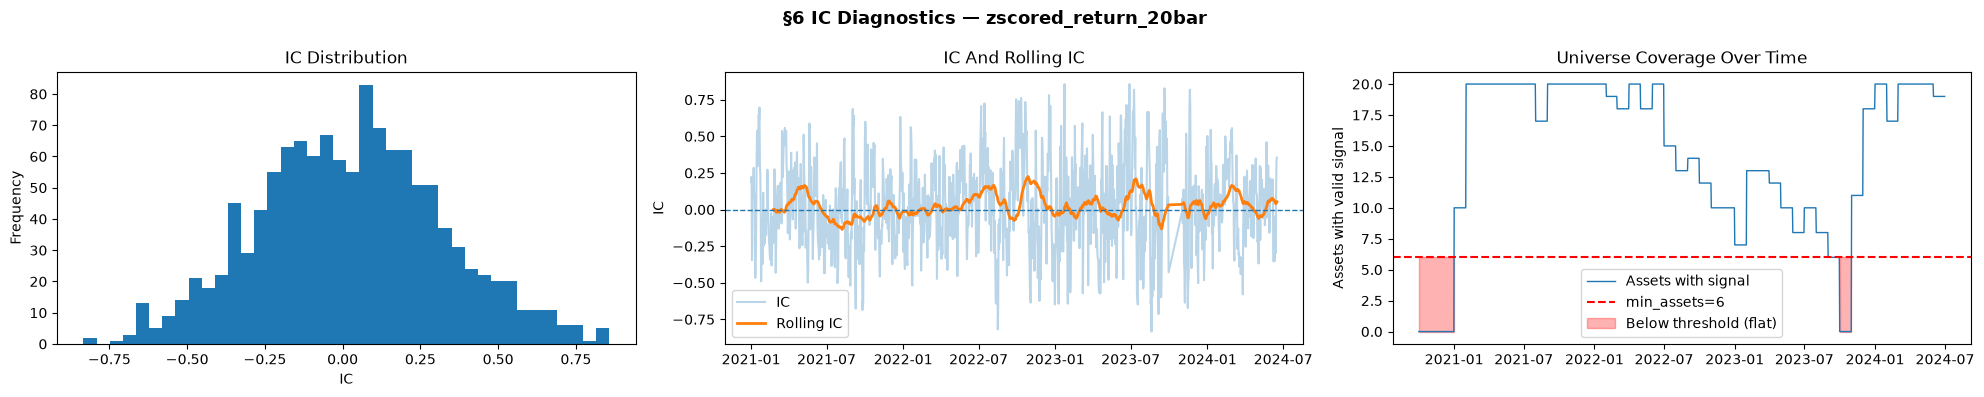

signal_label               zscored_return_20bar
selected_holding_period                      14
n_obs                                      1232
mean_ic                                0.026683
median_ic                              0.028571
std_ic                                 0.296992
t_stat_ic                              3.153572
t_stat_ic_nw                           1.538276
nw_lag                                       19
p05_ic                                -0.461124
p95_ic                                 0.537571
avg_assets_per_ts                     14.373996
avg_turnover_proxy                     1.071170
dtype: object

In [9]:
rolling_ic = rolling_mean(baseline_ic, settings["rolling_window_bars"])

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
fig.suptitle(f"\u00a76 IC Diagnostics \u2014 {signal_label}", fontsize=13, fontweight="bold")

axes[0].hist(baseline_ic.dropna(), bins=40)
axes[0].set_title("IC Distribution")
axes[0].set_xlabel("IC")
axes[0].set_ylabel("Frequency")

axes[1].plot(baseline_ic.index, baseline_ic, alpha=0.3, label="IC")
axes[1].plot(rolling_ic.index, rolling_ic, linewidth=2, label="Rolling IC")
axes[1].axhline(0.0, linestyle="--", linewidth=1)
axes[1].set_title("IC And Rolling IC")
axes[1].set_ylabel("IC")
axes[1].legend()

# Universe coverage over time. Bars below the min_assets threshold are
# periods where the strategy is flat.
coverage = signal.notna().sum(axis=1)
min_assets = settings["min_assets_per_timestamp"]
axes[2].plot(coverage.index, coverage, linewidth=1, label="Assets with signal")
axes[2].axhline(min_assets, linestyle="--", linewidth=1.5, color="red",
                label=f"min_assets={min_assets}")
axes[2].fill_between(coverage.index, coverage, min_assets,
                     where=(coverage < min_assets),
                     alpha=0.3, color="red", label="Below threshold (flat)")
axes[2].set_title("Universe Coverage Over Time")
axes[2].set_ylabel("Assets with valid signal")
axes[2].legend()

plt.tight_layout()
plt.show()

pd.Series(summary)

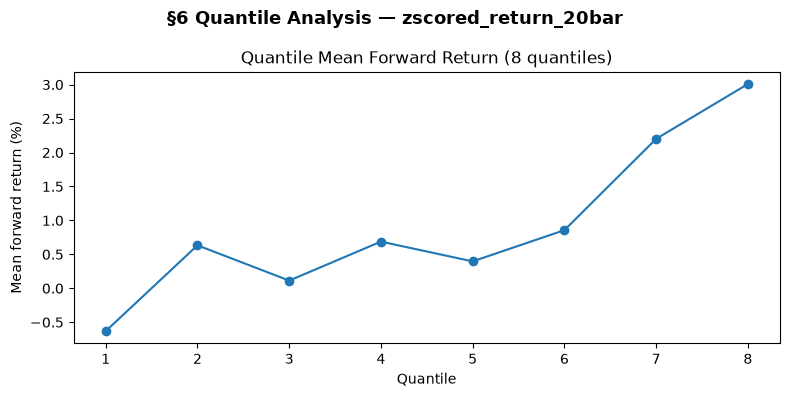

{'signal_label': 'zscored_return_20bar',
 'quantile_monotonicity_corr': 0.8837508008624879,
 'top_minus_bottom_mean': 0.03349119731056925}

In [10]:
n_quantiles = 8
# Use rebalance-date-subsampled signal so quantile buckets reflect actual
# decision points, not forward-filled stale values between rebalances.
quantile_table, quantile_spread_ts = quantile_analysis(
    signal_for_ic,
    fwd_ret_for_ic,
    n_quantiles=n_quantiles,
    returns_are_log=settings["log_returns"],
)

if not quantile_table.empty:
    monotonicity_corr = quantile_table["quantile"].corr(quantile_table["mean_fwd_ret"])
else:
    monotonicity_corr = np.nan

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle(f"\u00a76 Quantile Analysis \u2014 {signal_label}", fontsize=13, fontweight="bold")
if not quantile_table.empty:
    ax.plot(quantile_table["quantile"], quantile_table["mean_fwd_ret"] * 100, marker="o")
ax.set_title(f"Quantile Mean Forward Return ({n_quantiles} quantiles)")
ax.set_xlabel("Quantile")
ax.set_ylabel("Mean forward return (%)")
plt.tight_layout()
plt.show()

{
    "signal_label": signal_label,
    "quantile_monotonicity_corr": float(monotonicity_corr) if not pd.isna(monotonicity_corr) else np.nan,
    "top_minus_bottom_mean": float(quantile_spread_ts.mean()) if len(quantile_spread_ts) else np.nan,
}

## §7 Backtest

Equal-weight top/bottom quantile long/short portfolio, gross vs net after fees and half-spread. A momentum signal should show a Sharpe that degrades gradually with cost and long/short legs that both contribute positively. Cost sensitivity is reported across one-way taker-fee tiers (`fee_tier_grid_bps`); net returns are correlated to the benchmark to check for residual beta.

**Conventions.** The book rebalances every `holding_period_bars` on the freshest signal (decimation via `ic_rebalance_bars` is an IC-analysis device and does not feed the backtest). With `momentum_skip_bars >= 1` the signal at bar t only uses closes up to t−skip, so filling at close(t) already carries a full bar of information age, with no same-close leakage. Rebalances are netted at a single print; `fee_bps` and the half-spread are one-way rates charged on every fill (light backtest). Shorts are assumed available at no borrow cost; on spot they require margin (opening and rollover fees, eligible pairs only), which compounds over the 14-bar hold, so net Sharpe is an upper bound.


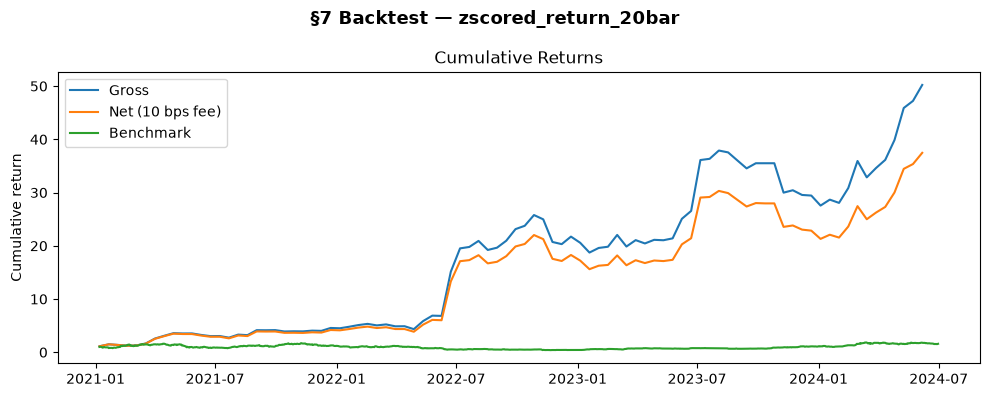

(        sharpe_net  max_drawdown_net  mean_turnover  annualized_turnover  \
 costs                                                                      
 gross     1.629356         -0.273451       1.533889            39.990675   
 5 bps     1.575120         -0.286335       1.533889            39.990675   
 10 bps    1.529903         -0.297381       1.533889            39.990675   
 20 bps    1.439417         -0.319017       1.533889            39.990675   
 40 bps    1.258254         -0.364755       1.533889            39.990675   
 
         mean_cost_per_period  total_net_return  
 costs                                           
 gross               0.000000         49.222248  
 5 bps               0.001841         41.809147  
 10 bps              0.003375         36.465901  
 20 bps              0.006442         27.678693  
 40 bps              0.012578         15.760728  ,
 {'signal_label': 'zscored_return_20bar',
  'long_leg_mean': 0.0021125505563221836,
  'short_leg_mean': 0.00

In [11]:
# Gross book plus one net book per one-way taker-fee tier (flat half-spread).
_bt_common = dict(
    signal_wide=signal_fresh,
    forward_return_wide=fwd_ret,
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
    execution_delay_bars=settings["execution_delay_bars"],
    returns_are_log=settings["log_returns"],
    holding_period_bars=selected_holding_period,
)
backtests = {"gross": run_light_backtest(fee_bps=0.0, half_spread_bps=0.0, **_bt_common)}
for fee in settings["fee_tier_grid_bps"]:
    backtests[f"{fee:g} bps"] = run_light_backtest(
        fee_bps=fee, half_spread_bps=settings["half_spread_bps"], **_bt_common
    )
cost_table = pd.DataFrame(
    {
        case: {
            "sharpe_net": bt["metrics"]["sharpe_net"],
            "max_drawdown_net": bt["metrics"]["max_drawdown_net"],
            "mean_turnover": bt["metrics"]["mean_turnover"],
            "annualized_turnover": bt["metrics"]["annualized_turnover"],
            "mean_cost_per_period": bt["metrics"]["mean_cost_per_period"],
            "total_net_return": float(bt["cum_net"].iloc[-1] - 1.0),
        }
        for case, bt in backtests.items()
    }
).T
cost_table.index.name = "costs"
base_bt = backtests[f"{settings['fee_bps']:g} bps"]

long_leg, short_leg = long_short_leg_returns(
    base_bt["weights"], fwd_ret, returns_are_log=settings["log_returns"]
)

# Forward benchmark simple return aligned to the strategy's stepped P&L. Used
# for market correlation and the beta diagnostics so that the bar at index t
# represents the move from t to t+H -- the same window over which the strategy
# realises its P&L.
benchmark_col = settings["benchmark_symbol"]
benchmark_close_wide = (
    close_wide[[benchmark_col]] if benchmark_col in close_wide.columns else close_wide
)
benchmark_fwd_log = compute_forward_returns(
    benchmark_close_wide,
    holding_period_bars=selected_holding_period,
    log_returns=settings["log_returns"],
)
if benchmark_col in close_wide.columns:
    benchmark_fwd_ret = benchmark_fwd_log[benchmark_col]
else:
    benchmark_fwd_ret = benchmark_fwd_log.mean(axis=1)
if settings["log_returns"]:
    benchmark_fwd_ret = np.exp(benchmark_fwd_ret) - 1.0

market_corr = market_correlation(base_bt["net_returns"], benchmark_fwd_ret)

if benchmark_col in benchmark_close_wide.columns:
    benchmark_px = benchmark_close_wide[benchmark_col]
else:
    benchmark_px = benchmark_close_wide.mean(axis=1)
benchmark_curve = benchmark_px.loc[benchmark_px.index >= base_bt["cum_net"].index[0]].ffill()
benchmark_curve = benchmark_curve / benchmark_curve.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle(f"\u00a77 Backtest \u2014 {signal_label}", fontsize=13, fontweight="bold")
ax.plot(base_bt["cum_gross"].index, base_bt["cum_gross"], label="Gross")
ax.plot(base_bt["cum_net"].index, base_bt["cum_net"], label=f"Net ({settings['fee_bps']:g} bps fee)")
ax.plot(benchmark_curve.index, benchmark_curve, label="Benchmark")
ax.set_title("Cumulative Returns")
ax.set_ylabel("Cumulative return")
ax.legend()
plt.tight_layout()
plt.show()

cost_table, {
    "signal_label": signal_label,
    "long_leg_mean": float(long_leg.mean()),
    "short_leg_mean": float(short_leg.mean()),
    "net_to_market_corr": market_corr,
}


### Beta-Neutral Variants — Residual Signal and Hedge Overlay

A controlled comparison of the two routes to market neutrality: residual momentum aims to build neutrality **into the signal**, while the hedge overlay neutralises **the book** after the fact. The 2×2 of {selected, residual} × {unhedged, hedged} isolates each mechanism under identical cost accounting.

The comparison is itself the finding: only the overlay reliably neutralises exposure. Residualising the *feature* only loosely controls the resulting long/short book, whose beta is set by which names fall in each quantile rather than by the residualisation. It therefore lowers ex-ante beta only modestly and not to zero, whereas the overlay sizes explicitly to the book's beta and drives it to ≈ 0. The realized-beta differences between variants sit within noise (~90 stepped P&L points). Read the residual rows as a neutrality comparison, not a strategy: its predictive IC is ≈ 0 (§5).

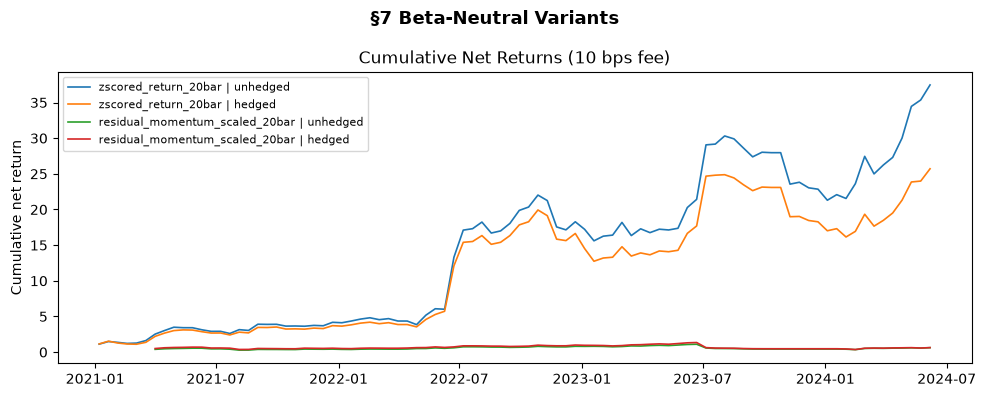

(                                           sharpe_net  max_drawdown_net  \
 variant                                                                   
 zscored_return_20bar | unhedged              1.529903         -0.297381   
 zscored_return_20bar | hedged                1.435314         -0.360693   
 residual_momentum_scaled_20bar | unhedged    0.202459         -0.685224   
 residual_momentum_scaled_20bar | hedged      0.174307         -0.730734   
 
                                            annualized_turnover  \
 variant                                                          
 zscored_return_20bar | unhedged                      39.990675   
 zscored_return_20bar | hedged                        39.377090   
 residual_momentum_scaled_20bar | unhedged            33.447988   
 residual_momentum_scaled_20bar | hedged              33.685821   
 
                                            mean_gross_exposure  \
 variant                                                          
 zsc

In [12]:
# --- Beta-neutral variants: {selected, residual} x {unhedged, hedged} --------
residual_raw_panel, residual_label = select_momentum_feature_panel(
    feature_pack=feature_pack,
    baseline_signal=signal_pack["raw_signal"],
    available_horizons=settings["feature_horizons_bars"],
    feature_family="residual",
    feature_horizon=feature_horizon,
    residual_feature=residual_feature,
)
residual_signal_fresh = build_selected_momentum_signal(
    raw_panel=residual_raw_panel,
    universe_mask=universe_mask,
    cross_sectional_transform=settings["cross_sectional_transform"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    apply_xsec_transform=apply_xsec_transform,
    apply_rebalance_decimation_flag=False,
)


# Hedge sized from XBT betas: the hedge trades XBT, so factor == instrument.
def _variant_backtest(sig_fresh, hedge, fee_bps=settings["fee_bps"],
                      half_spread_bps=settings["half_spread_bps"]):
    qw = build_quantile_weights(
        sig_fresh,
        top_quantile=settings["top_quantile"],
        bottom_quantile=settings["bottom_quantile"],
    )
    weights = (
        build_beta_hedged_weights(
            qw,
            betas_xbt,
            benchmark_symbol=settings["benchmark_symbol"],
            max_hedge_weight=settings["max_hedge_weight"],
        )
        if hedge
        else qw
    )
    return run_light_backtest(
        signal_wide=None,
        forward_return_wide=fwd_ret,
        fee_bps=fee_bps,
        half_spread_bps=half_spread_bps,
        execution_delay_bars=settings["execution_delay_bars"],
        returns_are_log=settings["log_returns"],
        holding_period_bars=selected_holding_period,
        weights_wide=weights,
    )


variant_rows = []
variant_books = {}
for sig_name, sig_fresh in [
    (signal_label, signal_fresh),
    (residual_label, residual_signal_fresh),
]:
    for hedge in [False, True]:
        bt = _variant_backtest(sig_fresh, hedge)
        beta_ts = portfolio_beta_series(bt["weights"], betas_xbt)
        realized = realized_beta_diagnostics(bt["net_returns"], benchmark_fwd_ret)
        key = f"{sig_name} | {'hedged' if hedge else 'unhedged'}"
        variant_books[key] = bt
        variant_rows.append(
            {
                "variant": key,
                "sharpe_net": bt["metrics"]["sharpe_net"],
                "max_drawdown_net": bt["metrics"]["max_drawdown_net"],
                "annualized_turnover": bt["metrics"]["annualized_turnover"],
                "mean_gross_exposure": bt["metrics"]["mean_gross_exposure"],
                "mean_abs_exante_beta": float(beta_ts["portfolio_beta"].abs().mean()),
                "realized_beta_full": realized["beta_full"],
                "realized_beta_down": realized["beta_down"],
            }
        )

variant_table = pd.DataFrame(variant_rows).set_index("variant")

# Fee-tier sensitivity for the fully neutral book (residual signal + hedge overlay).
_neutral_books = {"gross": _variant_backtest(residual_signal_fresh, True, 0.0, 0.0)}
for fee in settings["fee_tier_grid_bps"]:
    _neutral_books[f"{fee:g} bps"] = _variant_backtest(residual_signal_fresh, True, fee)
neutral_cost_table = pd.DataFrame(
    {
        case: {
            "sharpe_net": bt_n["metrics"]["sharpe_net"],
            "max_drawdown_net": bt_n["metrics"]["max_drawdown_net"],
            "annualized_turnover": bt_n["metrics"]["annualized_turnover"],
            "total_net_return": float(bt_n["cum_net"].iloc[-1] - 1.0),
        }
        for case, bt_n in _neutral_books.items()
    }
).T
neutral_cost_table.index.name = "costs"

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("\u00a77 Beta-Neutral Variants", fontsize=13, fontweight="bold")
for key, bt_v in variant_books.items():
    ax.plot(bt_v["cum_net"].index, bt_v["cum_net"], label=key, linewidth=1.2)
ax.set_title(f"Cumulative Net Returns ({settings['fee_bps']:g} bps fee)")
ax.set_ylabel("Cumulative net return")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

variant_table, neutral_cost_table


### Market-Neutrality Diagnostics

Confirms whether neutrality was actually achieved, using two instruments with very different sample sizes. **Ex-ante portfolio beta** (Σ wᵢβᵢ on ~1,300 bar-level weights) is the well-powered gauge and the quantity the hedge targets; the inline assertion checks the overlay cancels it to machine precision. **Realized beta**, split by up- and down-market regime, is estimated on the far smaller set of stepped P&L points: read it for the regime *asymmetry* a single full-sample correlation would hide, not as a precise point estimate.

Post-hedge ex-ante beta on fully covered bars: max |beta_p| = 4.44e-16 (OK)
Beta coverage of the book: mean 1.000, min 1.000

Realized betas below are estimated on ~90 stepped P&L points - read them jointly with the ex-ante series, not in isolation.


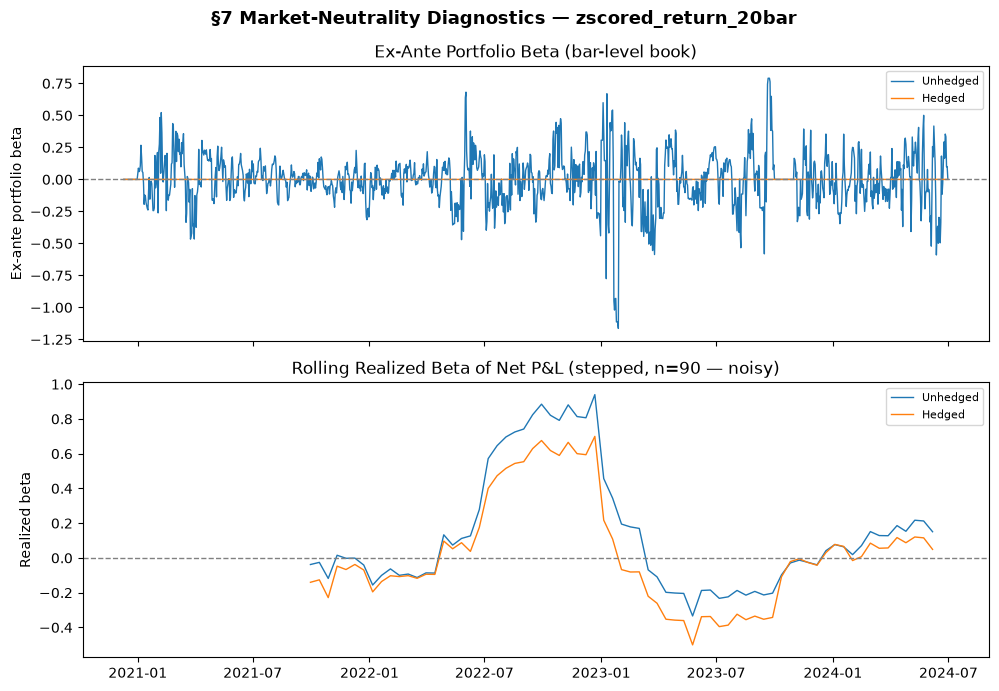

,n_obs,corr_full,beta_full,beta_up,beta_down,n_up,n_down
variant,,,,,,,
zscored_return_20bar | unhedged,90,0.046746,0.067162,-0.380064,0.113527,46,44
zscored_return_20bar | hedged,90,-0.034704,-0.048389,-0.460557,-0.053990,46,44
residual_momentum_scaled_20bar | unhedged,84,-0.096107,-0.117331,-0.138358,-0.330113,42,42
residual_momentum_scaled_20bar | hedged,84,-0.085274,-0.101332,-0.137747,-0.302945,42,42


In [13]:
# --- Ex-ante beta at bar level (~1,300 obs, vs ~90 stepped P&L points) -------
qw_bar = build_quantile_weights(
    signal_fresh,
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
)
hedged_bar = build_beta_hedged_weights(
    qw_bar,
    betas_xbt,
    benchmark_symbol=settings["benchmark_symbol"],
    max_hedge_weight=settings["max_hedge_weight"],
)
beta_unhedged = portfolio_beta_series(qw_bar, betas_xbt)
beta_hedged = portfolio_beta_series(hedged_bar, betas_xbt)

# Hard check: with full beta coverage and no hedge clipping, the hedge cancels
# the measured beta identically.
_full_cov = np.isclose(beta_hedged["beta_coverage"].fillna(0.0), 1.0)
if settings["max_hedge_weight"] is None and _full_cov.any():
    _worst = float(beta_hedged.loc[_full_cov, "portfolio_beta"].abs().max())
    assert _worst < 1e-10, f"hedged ex-ante beta should be ~0, got {_worst:.2e}"
    print(f"Post-hedge ex-ante beta on fully covered bars: max |beta_p| = {_worst:.2e} (OK)")
print(
    f"Beta coverage of the book: mean {float(beta_unhedged['beta_coverage'].mean()):.3f}, "
    f"min {float(beta_unhedged['beta_coverage'].min()):.3f}"
)

# --- Realized (regime-conditional) betas on the stepped net P&L -----------------
realized_rows = []
for key, bt_v in variant_books.items():
    d = realized_beta_diagnostics(bt_v["net_returns"], benchmark_fwd_ret)
    realized_rows.append(
        {
            "variant": key,
            "n_obs": d["n_obs"],
            "corr_full": d["corr_full"],
            "beta_full": d["beta_full"],
            "beta_up": d["beta_up"],
            "beta_down": d["beta_down"],
            "n_up": d["n_up"],
            "n_down": d["n_down"],
        }
    )
realized_table = pd.DataFrame(realized_rows).set_index("variant")
print(
    f"\nRealized betas below are estimated on ~{realized_table['n_obs'].iloc[0]} stepped "
    "P&L points - read them jointly with the ex-ante series, not in isolation."
)

_diag_unhedged = realized_beta_diagnostics(base_bt["net_returns"], benchmark_fwd_ret)
_diag_hedged = realized_beta_diagnostics(
    variant_books[f"{signal_label} | hedged"]["net_returns"], benchmark_fwd_ret
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle(f"\u00a77 Market-Neutrality Diagnostics \u2014 {signal_label}", fontsize=13, fontweight="bold")
axes[0].plot(beta_unhedged.index, beta_unhedged["portfolio_beta"], linewidth=1, label="Unhedged")
axes[0].plot(beta_hedged.index, beta_hedged["portfolio_beta"], linewidth=1, label="Hedged")
axes[0].axhline(0.0, linestyle="--", linewidth=1, color="gray")
axes[0].set_title("Ex-Ante Portfolio Beta (bar-level book)")
axes[0].set_ylabel("Ex-ante portfolio beta")
axes[0].legend(fontsize=8)
axes[1].plot(_diag_unhedged["rolling_beta"].index, _diag_unhedged["rolling_beta"], linewidth=1, label="Unhedged")
axes[1].plot(_diag_hedged["rolling_beta"].index, _diag_hedged["rolling_beta"], linewidth=1, label="Hedged")
axes[1].axhline(0.0, linestyle="--", linewidth=1, color="gray")
axes[1].set_title(f"Rolling Realized Beta of Net P&L (stepped, n={_diag_unhedged['n_obs']} — noisy)")
axes[1].set_ylabel("Realized beta")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

realized_table


## §8 Execution

Stress-tests the §7 base-cost backtest for stability and execution lag:

- **Rolling net Sharpe** over `rolling_window_bars` — shows performance stability over time
- **Execution delay** (0 vs 1 bar) — does the edge survive a one-bar fill lag? Because of the Jegadeesh–Titman skip, the base case already fills one full bar (24h) after the latest close the signal uses; the delayed case extends that to two.

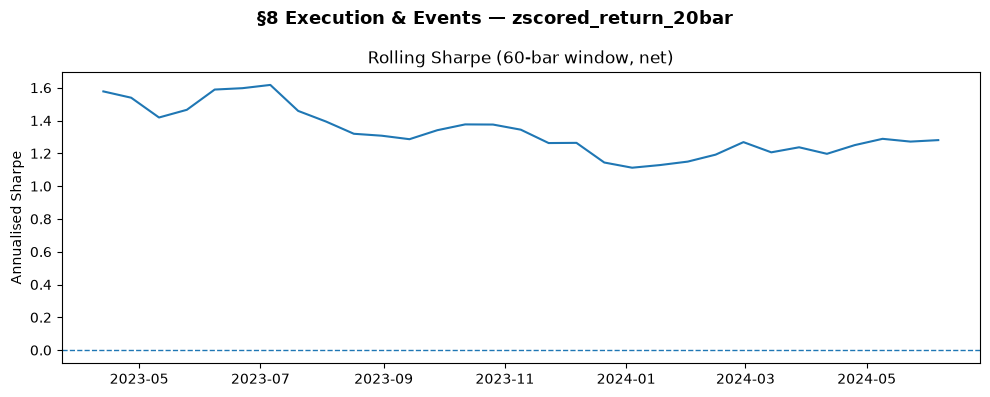

,execution_delay_bars,sharpe_net,total_net_return,mean_turnover
0,0,1.529903,36.465901,1.533889
1,1,0.842049,3.648273,1.603519


In [14]:
periods_per_year = base_bt["metrics"]["periods_per_year"]
roll_sharpe = rolling_sharpe(base_bt["net_returns"], settings["rolling_window_bars"], periods_per_year)

delay_rows = []
for delay in [0, 1]:
    bt_delay = run_light_backtest(
        signal_wide=signal_fresh,
        forward_return_wide=fwd_ret,
        top_quantile=settings["top_quantile"],
        bottom_quantile=settings["bottom_quantile"],
        fee_bps=settings["fee_bps"],
        half_spread_bps=settings["half_spread_bps"],
        execution_delay_bars=delay,
        returns_are_log=settings["log_returns"],
        holding_period_bars=selected_holding_period,
    )
    delay_rows.append(
        {
            "execution_delay_bars": delay,
            "sharpe_net": bt_delay["metrics"]["sharpe_net"],
            "total_net_return": float(bt_delay["cum_net"].iloc[-1] - 1.0),
            "mean_turnover": bt_delay["metrics"]["mean_turnover"],
        }
    )

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle(f"\u00a78 Execution & Events \u2014 {signal_label}", fontsize=13, fontweight="bold")
ax.plot(roll_sharpe.index, roll_sharpe)
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title(f"Rolling Sharpe ({settings['rolling_window_bars']}-bar window, net)")
ax.set_ylabel("Annualised Sharpe")
plt.tight_layout()
plt.show()

pd.DataFrame(delay_rows)


## §9 Robustness

Grid search over signal horizon × JT skip × holding period × universe size (cross-sectional rank; the transform axis is configurable). Each combination reports mean IC, NW-adjusted t-stat, net Sharpe, and train/test IC split. Results are sorted by mean IC; the heatmap below averages over nuisance parameters to show the horizon × holding surface.

Two additions correct the grid for selection: **selection-adjusted significance** (max-over-trials p-value for the best t-stat and a deflated Sharpe for the selected configuration) and **walk-forward evaluation with an embargo** (per-fold IC stability, plus re-selecting the best grid configuration at each fold using only past data and scoring it on the next fold). See the subsection after the heatmap.

In [15]:
# Betas are estimated once on the full panel; top_n=10 cells reuse them (the
# universe size gates index membership, not the betas).
robustness_table, grid_ic_store, grid_nw_store = run_momentum_grid(
    df_long,
    universe_df,
    settings,
    feature_family=feature_family,
    relative_feature=relative_feature,
    vol_feature=vol_feature,
    residual_feature=residual_feature,
    apply_xsec_transform=apply_xsec_transform,
    apply_rebalance_decimation=apply_rebalance_decimation_flag,
    beta_panel=betas_ew,
    market_returns=market_ret_ew,
)
robustness_table.head(20)


,signal_horizon,signal_label,relative_feature,vol_feature,skip_bars,apply_xsec_transform,apply_rebalance_decimation,holding,top_n,nw_lag,mean_ic,t_stat_ic,t_stat_ic_nw,sharpe_net,mean_turnover,annualized_turnover,train_mean_ic,test_mean_ic,train_t_stat_nw,test_t_stat_nw
142,20,zscored_return_20bar,minus_xsec_mean,zscored_return,3,True,True,40,10,39,0.040626,3.764525,1.911983,0.308098,1.446237,13.196909,0.048374,0.034217,1.658439,1.129711
126,20,zscored_return_20bar,minus_xsec_mean,zscored_return,2,True,True,40,10,39,0.040304,3.765660,1.924898,0.632353,1.397849,12.755376,0.047797,0.034106,1.705810,1.118971
104,20,zscored_return_20bar,minus_xsec_mean,zscored_return,1,True,True,14,10,19,0.040207,3.875381,1.967916,1.086867,1.501852,39.155423,0.019869,0.056394,0.653547,2.051219
110,20,zscored_return_20bar,minus_xsec_mean,zscored_return,1,True,True,40,10,39,0.039049,3.627986,1.807482,0.365795,1.521505,13.883737,0.049328,0.030545,1.683621,0.981962
120,20,zscored_return_20bar,minus_xsec_mean,zscored_return,2,True,True,14,10,19,0.037462,3.668084,1.926957,0.692780,1.568519,40.893519,0.031901,0.041887,1.105607,1.582642
127,20,zscored_return_20bar,minus_xsec_mean,zscored_return,2,True,True,40,20,39,0.036713,3.984440,1.968042,0.709122,1.496237,13.653159,0.051400,0.024563,2.407246,0.855448
106,20,zscored_return_20bar,minus_xsec_mean,zscored_return,1,True,True,21,10,20,0.036709,3.644892,1.759281,1.258955,1.730556,30.078704,0.045288,0.029811,1.376237,1.111382
143,20,zscored_return_20bar,minus_xsec_mean,zscored_return,3,True,True,40,20,39,0.036565,3.940804,1.960531,0.062224,1.552151,14.163374,0.051521,0.024192,2.432707,0.840104
111,20,zscored_return_20bar,minus_xsec_mean,zscored_return,1,True,True,40,20,39,0.034834,3.766514,1.796259,0.214922,1.544624,14.094691,0.050303,0.022038,2.291414,0.736652
136,20,zscored_return_20bar,minus_xsec_mean,zscored_return,3,True,True,14,10,19,0.032463,3.236152,1.677396,0.845406,1.561111,40.700397,0.043157,0.023952,1.510708,0.911423


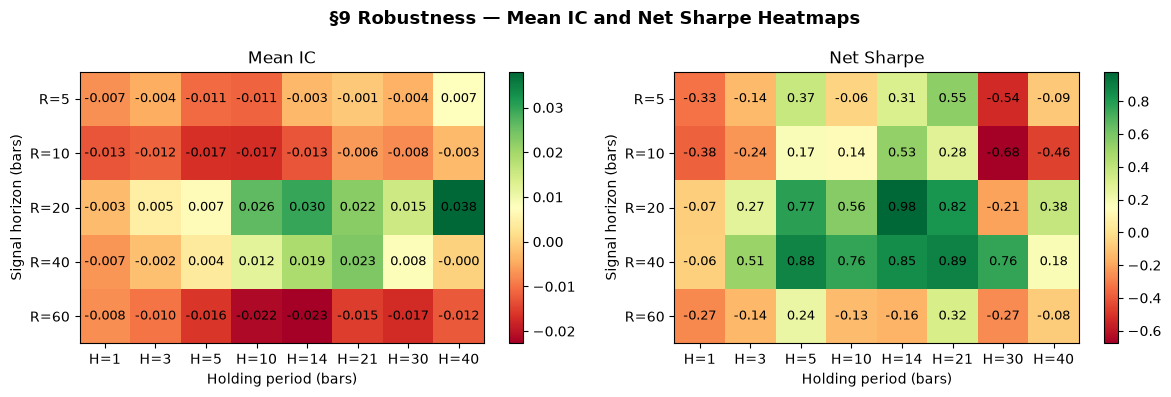

In [16]:
# Mean IC and Net Sharpe by signal horizon × holding period
# (averaged over skip / universe size). A heatmap reads the
# parameter surface at a glance, where many near-identical top rows do not.
if not robustness_table.empty:
    pivot_ic = (
        robustness_table
        .groupby(["signal_horizon", "holding"])["mean_ic"]
        .mean()
        .unstack("holding")
    )
    pivot_sharpe = (
        robustness_table
        .groupby(["signal_horizon", "holding"])["sharpe_net"]
        .mean()
        .unstack("holding")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("§9 Robustness — Mean IC and Net Sharpe Heatmaps",
                 fontsize=13, fontweight="bold")

    for ax, pivot, title, fmt in [
        (axes[0], pivot_ic,     "Mean IC",    "{:.3f}"),
        (axes[1], pivot_sharpe, "Net Sharpe", "{:.2f}"),
    ]:
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels([f"H={c}" for c in pivot.columns])
        ax.set_yticklabels([f"R={r}" for r in pivot.index])
        ax.set_xlabel("Holding period (bars)")
        ax.set_ylabel("Signal horizon (bars)")
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, fmt.format(pivot.values[i, j]),
                        ha="center", va="center", fontsize=9, color="black")

    plt.tight_layout()
    plt.show()

### Selection-Adjusted Significance & Walk-Forward

The grid above reports full-sample statistics for every combination — sorting it and quoting the winner is a **max-statistic**, not an unbiased estimate. Two corrections:

1. **Max-over-trials p-value** for the best NW t-stat: the correct null is the maximum of N trials, `1 − Φ(t)^N`. Trials are correlated, so the p-value is bracketed between the number of independent feature families and the total trial count. Alongside it, the **deflated Sharpe ratio** (Bailey–López de Prado) reports the probability that the selected configuration's true Sharpe exceeds the expected maximum of N no-skill trials; values near 0.5 mean the winner is indistinguishable from selection luck.
2. **Walk-forward with embargo**: per-fold IC of the selected signal over contiguous blocks (an embargo of the last overlapping lag separates folds so window overlap cannot leak), plus an out-of-sample grid evaluation that re-selects the best configuration on an expanding window of *past* observations and scores it on the next fold only. The pooled out-of-sample IC is what a fresh allocator following this process would actually have earned. A single train/test split cannot distinguish regime change from decay, and it quietly recycles test data once a winner is quoted.


In [17]:
# --- 1) Selection-adjusted significance -----------------------------------------
n_feature_trials = len(feature_ic_table)   # section 5 feature scan
n_grid_trials    = len(robustness_table)   # section 9 grid
_best_t = float(robustness_table["t_stat_ic_nw"].max())

# Trials are correlated -> bracket the p-value between "independent families"
# and "every trial independent".
_n_families = 4  # core, relative, vol-adjusted, residual momentum
for _n in [_n_families, n_feature_trials + n_grid_trials]:
    print(f"P(max of {_n:>3} null trials >= t={_best_t:.2f}) = "
          f"{max_over_trials_pvalue(_best_t, _n):.4f}")

# Deflated Sharpe of the selected configuration vs the grid's trial distribution
# (all Sharpes converted to per-period units before comparing).
_ppy_base = float(base_bt["metrics"]["periods_per_year"])
_bars_per_year = _ppy_base * selected_holding_period
_sr_period_rows = robustness_table["sharpe_net"] / np.sqrt(_bars_per_year / robustness_table["holding"])
_net = base_bt["net_returns"].dropna()
_dsr = deflated_sharpe_ratio(
    sharpe=float(base_bt["metrics"]["sharpe_net"]) / np.sqrt(_ppy_base),
    n_obs=len(_net),
    n_trials=n_grid_trials,
    var_sharpe=float(_sr_period_rows.var(ddof=1)),
    skew=float(_net.skew()),
    kurt=float(_net.kurt()) + 3.0,
)
print(f"\nDeflated Sharpe (selected config, {n_grid_trials} trials): "
      f"P(true SR > expected max of noise) = {_dsr['deflated_sharpe_prob']:.3f} "
      f"(expected max per-period SR under null: {_dsr['expected_max_sharpe']:.4f})")

# --- 2) Walk-forward with embargo -------------------------------------------------
_embargo = signal_nw_lag + 1  # last overlapping lag of the IC series (subsampled units)
wf_table = walk_forward_ic_table(
    baseline_ic, n_folds=5, embargo_obs=_embargo, nw_lag=signal_nw_lag
)
print("\n=== Walk-forward IC (selected signal) ===")
print(wf_table.to_string())

wf_sel_table, wf_pooled = walk_forward_selection(
    grid_ic_store,
    n_folds=5,
    embargo_obs=max(grid_nw_store.values()) + 1,
    nw_lag_by_config=grid_nw_store,
)
print("\n=== Walk-forward grid selection (select on past, score on next fold) ===")
print(wf_sel_table.to_string())
print(f"\nPooled out-of-sample IC: mean={wf_pooled['mean_ic']:.4f}, "
      f"NW t={wf_pooled['t_stat_ic_nw']:.2f} (n={wf_pooled['n_obs']})")


P(max of   4 null trials >= t=1.97) = 0.0946
P(max of 275 null trials >= t=1.97) = 0.9989

Deflated Sharpe (selected config, 240 trials): P(true SR > expected max of noise) = 0.278 (expected max per-period SR under null: 0.3384)

=== Walk-forward IC (selected signal) ===
                         start                       end  n_obs   mean_ic  t_stat_ic_nw
fold                                                                                   
1    2021-01-01 00:00:00+00:00 2021-09-03 00:00:00+00:00    246  0.006953      0.188347
2    2021-09-24 00:00:00+00:00 2022-05-07 00:00:00+00:00    226 -0.000659     -0.030624
3    2022-05-28 00:00:00+00:00 2023-01-09 00:00:00+00:00    227  0.056582      1.009382
4    2023-01-30 00:00:00+00:00 2023-09-12 00:00:00+00:00    226  0.018408      0.443245
5    2023-11-03 00:00:00+00:00 2024-06-16 00:00:00+00:00    227  0.030879      0.915169

=== Walk-forward grid selection (select on past, score on next fold) ===
            selected_config  selection

### Residual Momentum — Walk-Forward Stability

**Hypothesis.** If the momentum book's returns are market-beta exposure rather than cross-sectional alpha, momentum computed on beta-residualised returns should have no predictive power. Residual momentum (Blitz, Huij & Martens) ranks assets on trailing returns net of their market exposure; in equities it is more robust than raw momentum, which makes it the natural test here.

**Test, fixed before the results.** One configuration (the scaled residual variant at the selected 20-bar horizon and 14-bar hold, using the equal-weight-index betas from §4) and one pass criterion: positive, same-sign IC across five contiguous, embargoed sub-periods of the research sample. A sweep over the beta-estimation window and shrinkage then checks that the verdict does not depend on one beta configuration.


In [18]:
# --- Residual momentum at the pre-specified configuration --------------------
_D_r = max(int(settings["ic_rebalance_bars"]), 1)
resid_sig_ic = residual_signal_fresh.iloc[::_D_r] if _D_r > 1 else residual_signal_fresh
resid_fwd_ic = fwd_ret.reindex(resid_sig_ic.index)
resid_nw_lag = (max(int(selected_holding_period), int(feature_horizon)) - 1) // _D_r
resid_ic_series = compute_ic_series(resid_sig_ic, resid_fwd_ic, min_assets=min_assets)
resid_summary = ic_summary(resid_ic_series, nw_lag=resid_nw_lag)
print(
    f"Residual momentum ({residual_label}, H={selected_holding_period}): "
    f"mean IC={resid_summary['mean_ic']:.4f}, NW t={resid_summary['t_stat_ic_nw']:.2f} "
    f"(n={resid_summary['n_obs']})"
)

wf_resid = walk_forward_ic_table(
    resid_ic_series, n_folds=5, embargo_obs=resid_nw_lag + 1, nw_lag=resid_nw_lag
)
print("\n=== Walk-forward IC (residual momentum, pre-specified variant) ===")
print(wf_resid.to_string())

# --- Robustness note: null is not an artifact of the beta configuration ------
# Same residual-signal construction as above; the sweep varies only the beta
# estimation window and shrinkage.
def _residual_scaled_signal(betas):
    return build_residual_momentum_signal(
        signal_pack["return_wide"], betas, market_ret_ew,
        horizon=feature_horizon,
        skip_bars=settings["momentum_skip_bars"],
        feature="residual_momentum_scaled",
        universe_mask=universe_mask,
        cross_sectional_transform=settings["cross_sectional_transform"],
        min_assets_per_timestamp=settings["min_assets_per_timestamp"],
        apply_xsec_transform=apply_xsec_transform,
    )


_sens = []
for _w in [60, 90, 120]:
    for _lam in [0.0, 0.2, 0.5]:
        _betas_s = estimate_rolling_betas(
            return_wide_traded, market_ret_ew, window_bars=_w,
            shrinkage=_lam, shrink_target=settings["beta_shrink_target"],
        )
        _sig_s = _residual_scaled_signal(_betas_s)
        _sig_s_ic = _sig_s.iloc[::_D_r] if _D_r > 1 else _sig_s
        _stats_s = ic_summary(
            compute_ic_series(_sig_s_ic, fwd_ret.reindex(_sig_s_ic.index), min_assets=min_assets),
            nw_lag=resid_nw_lag,
        )
        _sens.append((_stats_s["mean_ic"], _stats_s["t_stat_ic_nw"]))

_ic_lo, _ic_hi = min(r[0] for r in _sens), max(r[0] for r in _sens)
_t_absmax = max(abs(r[1]) for r in _sens)
print(
    f"\nRobustness: across beta windows {{60, 90, 120}} x shrinkage {{0, 0.2, 0.5}}, "
    f"mean IC stays in [{_ic_lo:.4f}, {_ic_hi:.4f}] (max |NW t| = {_t_absmax:.2f}) — "
    f"the null result is not an artifact of the beta-estimation configuration."
)


Residual momentum (residual_momentum_scaled_20bar, H=14): mean IC=-0.0025, NW t=-0.10 (n=1054)

=== Walk-forward IC (residual momentum, pre-specified variant) ===
                         start                       end  n_obs   mean_ic  t_stat_ic_nw
fold                                                                                   
1    2021-03-31 00:00:00+00:00 2021-10-26 00:00:00+00:00    210 -0.080889     -1.797281
2    2021-11-16 00:00:00+00:00 2022-05-25 00:00:00+00:00    191  0.046056      0.692563
3    2022-06-15 00:00:00+00:00 2022-12-22 00:00:00+00:00    191 -0.011670     -0.263151
4    2023-01-12 00:00:00+00:00 2023-07-21 00:00:00+00:00    191  0.022276      0.269756
5    2023-08-11 00:00:00+00:00 2024-06-16 00:00:00+00:00    191  0.016693      0.357778

Robustness: across beta windows {60, 90, 120} x shrinkage {0, 0.2, 0.5}, mean IC stays in [-0.0067, 0.0100] (max |NW t| = 0.38) — the null result is not an artifact of the beta-estimation configuration.


## §10 Detailed Findings

**Selection bias**
- The selected signal (z-scored 20-bar return, 14-bar hold) has raw IC t 3.15, but it is the maximum over 35 features and a parameter grid. Newey-West correction alone drops it to 1.54, before any multiple-testing penalty (§5).
- The best grid row (NW t 1.97) has a max-over-trials p-value of 0.09 granting only 4 independent feature families, and ≈ 1.0 against all 275 trials. The deflated Sharpe probability of the selected backtest is 0.28, far short of the 0.95 a genuine edge would need: its Sharpe sits below the expected maximum of 240 noise trials (§9).
- The winner is a volatility-standardised return, not canonical momentum; the plain trailing-return features have IC near zero, and the largest |t-stats| in the scan are negative (60-bar return features, raw t ≈ −7.0) (§5).

**Out-of-sample behaviour**
- Per-fold IC of the selected signal is never significant (largest NW t 1.0). Expanding-window re-selection chooses three different configurations across four folds, and the pooled out-of-sample IC is 0.003 (NW t 0.12) (§9).

**Market exposure**
- The dollar-neutral book has mean |ex-ante β| ≈ 0.16 against XBT/USD, with offsetting regime betas (β_up ≈ −0.38, β_down ≈ +0.11) behind a full-sample correlation of 0.05 measured on only ~90 stepped periods (§7).
- Residual momentum (pre-specified) has mean IC −0.003 (NW t −0.10), flips sign across the five walk-forward folds, and stays flat across beta windows {60, 90, 120} × shrinkage {0, 0.2, 0.5} (§9). The apparent momentum was market exposure, not cross-sectional alpha.
- The benchmark hedge drives ex-ante β to zero at matched gross exposure; net Sharpe moves from 1.53 to 1.44 (§7).

**Costs and execution**
- Annualised turnover is ~40×, so fees matter less than for the reversal sleeve: net Sharpe is 1.58 at the 5 bps top tier, 1.53 at the 10 bps headline and 1.26 at the 40 bps retail rate (gross 1.63). A one-bar execution delay roughly halves it (0.84) (§7, §8). These figures inherit the selection bias above, exclude short borrow costs, and are not evidence of a tradable edge.
